# Wav2Vec2 (Audio Transformer) — Fine-Tuning Baseline

This notebook fine-tunes a pre-trained `wav2vec2-base` model for 3-class language identification (English, Malay, Mandarin) using your temporally split audio segments. We freeze the encoder and train only the classification head for a fast, stable baseline.

In [1]:
# Setup and Dependencies
import subprocess, sys

packages = [
    'torch', 'librosa', 'numpy', 'pandas', 'matplotlib',
    'transformers', 'ipywidgets', 'scikit-learn', 'optuna', 'joblib'
]
print('Checking dependencies...')
for pkg in packages:
    try:
        __import__(pkg)
        print(f'{pkg} available')
    except ImportError:
        print(f'Installing {pkg}...')
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg])
print('All dependencies ready')


Checking dependencies...
torch available
librosa available
numpy available
pandas available
matplotlib available
transformers available
ipywidgets available
Installing scikit-learn...
optuna available
joblib available
All dependencies ready


In [2]:
import warnings
from transformers import logging as hf_logging

# Set transformers to error level (suppresses info/warnings)
hf_logging.set_verbosity_error()

# Suppress specific deprecation warnings
warnings.filterwarnings('ignore', category=UserWarning, message='.*gradient_checkpointing.*')
warnings.filterwarnings('ignore', message='.*Some weights of.*were not initialized.*')

In [3]:
# GPU Check
import torch

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)} | CUDA: {torch.version.cuda}")
else:
    print('GPU not available - wav2vec2 training will be slow')

globals()['device'] = device


Using device: cuda
GPU: NVIDIA GeForce GTX 1650 | CUDA: 11.8


In [4]:
# Config and Paths
import os
AUDIO_DIR = os.path.join(os.getcwd(), 'Dataset', 'audio_active')
SAMPLE_RATE = 16000
SEGMENT_LENGTH = 10  # 10s segments for wav2vec2
LANG_MAP = {'en': 0, 'ms': 1, 'zh': 2}
LANG_NAMES = ['English', 'Malay', 'Mandarin']
BATCH_SIZE = 8  # memory-friendly for GPU
NUM_EPOCHS = 1  # Quick test run on full 7.5h dataset
LEARNING_RATE = 1e-3

# Train/val/test split ratios
TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
TEST_RATIO = 0.15

print('Audio dir:', AUDIO_DIR)
print('Segment length:', SEGMENT_LENGTH)
print('Split: Train/Val/Test =', f'{TRAIN_RATIO}/{VAL_RATIO}/{TEST_RATIO}')

Audio dir: c:\Users\Aaron Lim\Dropbox\PC\Documents\1School\FYP\Dataset\audio_active
Segment length: 10
Split: Train/Val/Test = 0.7/0.15/0.15


In [5]:
# Load 7.5h audio files and create temporal splits
from typing import List, Tuple
import librosa

print('Loading 7.5-hour audio files...')
audio_data = {}
for lang_code in LANG_MAP.keys():
    audio_file = os.path.join(AUDIO_DIR, f'{lang_code}_7.5h.wav')
    if os.path.exists(audio_file):
        print(f'  Loading {lang_code}_7.5h.wav...')
        waveform, sr = librosa.load(audio_file, sr=SAMPLE_RATE)
        duration_min = len(waveform) / SAMPLE_RATE / 60
        print(f'    {lang_code}: {duration_min:.1f} minutes')
        audio_data[lang_code] = waveform
    else:
        print(f'     {lang_code}: missing {audio_file}')

# Create temporal train/val/test splits (70/15/15) per language
print('\nCreating temporal splits...')
train_files, train_labels = [], []
val_files, val_labels = [], []
test_files, test_labels = [], []

for lang_code, waveform in audio_data.items():
    total_len = len(waveform)
    train_end = int(total_len * TRAIN_RATIO)
    val_end = train_end + int(total_len * VAL_RATIO)
    
    # Create temporary files for each split
    import tempfile
    import soundfile as sf
    
    # Train split
    train_file = os.path.join(AUDIO_DIR, f'{lang_code}_train_temp.wav')
    sf.write(train_file, waveform[:train_end], SAMPLE_RATE)
    train_files.append(train_file)
    train_labels.append(LANG_MAP[lang_code])
    
    # Val split
    val_file = os.path.join(AUDIO_DIR, f'{lang_code}_val_temp.wav')
    sf.write(val_file, waveform[train_end:val_end], SAMPLE_RATE)
    val_files.append(val_file)
    val_labels.append(LANG_MAP[lang_code])
    
    # Test split
    test_file = os.path.join(AUDIO_DIR, f'{lang_code}_test_temp.wav')
    sf.write(test_file, waveform[val_end:], SAMPLE_RATE)
    test_files.append(test_file)
    test_labels.append(LANG_MAP[lang_code])
    
    print(f'  {lang_code}: Train {train_end/SAMPLE_RATE/60:.1f}min | Val {(val_end-train_end)/SAMPLE_RATE/60:.1f}min | Test {(total_len-val_end)/SAMPLE_RATE/60:.1f}min')

print(f'\n Splits ready: {len(train_files)} train, {len(val_files)} val, {len(test_files)} test')

Loading 7.5-hour audio files...
  Loading en_7.5h.wav...
    en: 450.2 minutes
  Loading ms_7.5h.wav...
    ms: 450.2 minutes
  Loading zh_7.5h.wav...
    zh: 450.1 minutes

Creating temporal splits...
  en: Train 315.1min | Val 67.5min | Test 67.5min
  ms: Train 315.1min | Val 67.5min | Test 67.5min
  zh: Train 315.1min | Val 67.5min | Test 67.5min

 Splits ready: 3 train, 3 val, 3 test


In [5]:
# Optional: switch to 1-hour compiled dataset for faster grid search
import os

USE_ONE_HOUR = True  # set False to use full 7.5h data
ONE_HOUR_DIR = os.path.join(os.getcwd(), 'Dataset', 'compiled_audio')
ONE_HOUR_FILES = {
    'en': 'en_1h.wav',
    'ms': 'ms_1h.wav',
    'zh': 'zh_1h.wav',
}

if USE_ONE_HOUR:
    print('Using 1-hour compiled audio per language for faster tuning...')
    audio_data = {}
    for lang_code, filename in ONE_HOUR_FILES.items():
        audio_file = os.path.join(ONE_HOUR_DIR, filename)
        if os.path.exists(audio_file):
            waveform, sr = librosa.load(audio_file, sr=SAMPLE_RATE)
            duration_min = len(waveform) / SAMPLE_RATE / 60
            print(f'   {lang_code}: {duration_min:.1f} minutes from {filename}')
            audio_data[lang_code] = waveform
        else:
            print(f'   {lang_code}: missing {audio_file} — falling back to full 7.5h data')

    if len(audio_data) == len(LANG_MAP):
        train_files, train_labels = [], []
        val_files, val_labels = [], []
        test_files, test_labels = [], []

        for lang_code, waveform in audio_data.items():
            total_len = len(waveform)
            train_end = int(total_len * TRAIN_RATIO)
            val_end = train_end + int(total_len * VAL_RATIO)

            import soundfile as sf
            train_file = os.path.join(ONE_HOUR_DIR, f'{lang_code}_train_temp.wav')
            val_file = os.path.join(ONE_HOUR_DIR, f'{lang_code}_val_temp.wav')
            test_file = os.path.join(ONE_HOUR_DIR, f'{lang_code}_test_temp.wav')

            sf.write(train_file, waveform[:train_end], SAMPLE_RATE)
            sf.write(val_file, waveform[train_end:val_end], SAMPLE_RATE)
            sf.write(test_file, waveform[val_end:], SAMPLE_RATE)

            train_files.append(train_file); train_labels.append(LANG_MAP[lang_code])
            val_files.append(val_file); val_labels.append(LANG_MAP[lang_code])
            test_files.append(test_file); test_labels.append(LANG_MAP[lang_code])

            print(f'  {lang_code}: Train {train_end/SAMPLE_RATE/60:.1f}min | Val {(val_end-train_end)/SAMPLE_RATE/60:.1f}min | Test {(total_len-val_end)/SAMPLE_RATE/60:.1f}min')

        print(f' 1-hour splits ready: {len(train_files)} train, {len(val_files)} val, {len(test_files)} test')
    else:
        print('One-hour data incomplete; retaining full 7.5h splits.')
else:
    print('Using full 7.5h data (default).')


Using 1-hour compiled audio per language for faster tuning...
   en: 60.1 minutes from en_1h.wav
   ms: 60.1 minutes from ms_1h.wav
   zh: 60.2 minutes from zh_1h.wav
  en: Train 42.1min | Val 9.0min | Test 9.0min
  ms: Train 42.0min | Val 9.0min | Test 9.0min
  zh: Train 42.2min | Val 9.0min | Test 9.0min
 1-hour splits ready: 3 train, 3 val, 3 test


In [ ]:
# Hyperparameter Grid Search (cached models/processors, reused dataloaders, with progress bars)
import os
import torch
import torch.optim as optim
import torch.nn.functional as F
from transformers import Wav2Vec2Processor, Wav2Vec2ForSequenceClassification
from torch.utils.data import DataLoader, Dataset
from tqdm.notebook import tqdm
import numpy as np
import librosa
import pandas as pd

MODEL_NAME = 'facebook/wav2vec2-base'
CACHE_DIR = os.path.join(os.getcwd(), 'hf_cache')

# Grid Search Parameters (3 values each = 27 total combinations)
RUN_GRID_SEARCH = True
GRID_PARAMS = {
    'learning_rate': [0.0001, 0.0005, 0.001],
    'batch_size': [8, 16, 24],
    'num_epochs': [1, 2, 3],
}

if RUN_GRID_SEARCH:
    print('Starting Grid Search Hyperparameter Tuning...')
    total_combos = len(GRID_PARAMS['learning_rate']) * len(GRID_PARAMS['batch_size']) * len(GRID_PARAMS['num_epochs'])
    print(f'Total combinations: {total_combos}\n')
    print('Search space:')
    print('  Learning rates: [0.0001, 0.0005, 0.001]')
    print('  Batch sizes: [8, 16, 24]')
    print('  Num epochs: [1, 2, 3]\n')

    # Processor cached once (no re-downloads)
    processor = Wav2Vec2Processor.from_pretrained(MODEL_NAME, cache_dir=CACHE_DIR)

    # Collate uses cached processor
    def collate_fn(batch):
        waveforms = [x[0] for x in batch]
        labels = torch.tensor([x[1] for x in batch], dtype=torch.long)
        inputs = processor(waveforms, sampling_rate=SAMPLE_RATE, return_tensors='pt', padding=True)
        iv = inputs['input_values']
        if iv.ndim == 3 and iv.shape[0] == 1:
            inputs['input_values'] = iv.squeeze(0)
            if 'attention_mask' in inputs and inputs['attention_mask'].ndim == 3:
                inputs['attention_mask'] = inputs['attention_mask'].squeeze(0)
        return inputs, labels

    # Dataset reused across all trials
    class Wav2Vec2Dataset(Dataset):
        def __init__(self, audio_files, labels, segment_length=10, sr=16000):
            self.audio_files = audio_files
            self.labels = labels
            self.segment_length = segment_length
            self.sr = sr
            self.segment_samples = segment_length * sr
            self.segments = []
            for idx, file_path in enumerate(audio_files):
                try:
                    duration = librosa.get_duration(path=file_path)
                    num_segments = int(duration // segment_length)
                    for seg_idx in range(num_segments):
                        self.segments.append((idx, seg_idx))
                except Exception:
                    pass

        def __len__(self):
            return len(self.segments)

        def __getitem__(self, idx):
            file_idx, seg_idx = self.segments[idx]
            file_path = self.audio_files[file_idx]
            label = self.labels[file_idx]
            offset = seg_idx * self.segment_length
            y, sr = librosa.load(file_path, sr=self.sr, offset=offset, duration=self.segment_length, mono=True)
            if len(y) < self.segment_samples:
                y = np.pad(y, (0, self.segment_samples - len(y)))
            return y.astype(np.float32), label

    train_ds = Wav2Vec2Dataset(train_files, train_labels, SEGMENT_LENGTH, SAMPLE_RATE)
    val_ds = Wav2Vec2Dataset(val_files, val_labels, SEGMENT_LENGTH, SAMPLE_RATE)

    # Cache dataloaders by batch size so they are built once per unique batch size
    loader_cache = {}

    def get_loaders(batch_size):
        if batch_size not in loader_cache:
            loader_cache[batch_size] = (
                DataLoader(train_ds, batch_size=batch_size, shuffle=True, collate_fn=collate_fn),
                DataLoader(val_ds, batch_size=batch_size, shuffle=False, collate_fn=collate_fn),
            )
        return loader_cache[batch_size]

    results = []
    trial_num = 0

    for lr in GRID_PARAMS['learning_rate']:
        for batch_size in GRID_PARAMS['batch_size']:
            train_loader, val_loader = get_loaders(batch_size)
            for num_epochs in GRID_PARAMS['num_epochs']:
                trial_num += 1
                print(f"\n{'='*60}")
                print(f"Trial {trial_num}: lr={lr:.5f}, batch_size={batch_size}, epochs={num_epochs}")
                print(f"{'='*60}")

                # Build model (weights pulled from local cache if already downloaded)
                model = Wav2Vec2ForSequenceClassification.from_pretrained(
                    MODEL_NAME,
                    num_labels=3,
                    problem_type='single_label_classification',
                    cache_dir=CACHE_DIR,
                ).to(device)

                # Freeze encoder
                for p in model.wav2vec2.parameters():
                    p.requires_grad = False

                optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)

                best_val_acc = 0.0
                for epoch in range(num_epochs):
                    # Train
                    model.train()
                    train_correct, train_total = 0, 0
                    for inputs, labels in tqdm(train_loader, desc=f'Epoch {epoch+1} Train', leave=False):
                        inputs = {k: v.to(device) for k, v in inputs.items()}
                        labels = labels.to(device)
                        optimizer.zero_grad()
                        outputs = model(**inputs)
                        loss = F.cross_entropy(outputs.logits, labels)
                        loss.backward()
                        optimizer.step()
                        preds = outputs.logits.argmax(dim=1)
                        train_correct += (preds == labels).sum().item()
                        train_total += labels.size(0)
                    train_acc = 100.0 * train_correct / train_total

                    # Validate
                    model.eval()
                    val_correct, val_total = 0, 0
                    with torch.no_grad():
                        for inputs, labels in tqdm(val_loader, desc=f'Epoch {epoch+1} Val', leave=False):
                            inputs = {k: v.to(device) for k, v in inputs.items()}
                            labels = labels.to(device)
                            outputs = model(**inputs)
                            preds = outputs.logits.argmax(dim=1)
                            val_correct += (preds == labels).sum().item()
                            val_total += labels.size(0)
                    val_acc = 100.0 * val_correct / val_total
                    best_val_acc = max(best_val_acc, val_acc)
                    print(f"  Epoch {epoch+1}: Train {train_acc:.2f}% | Val {val_acc:.2f}%")

                results.append({
                    'trial': trial_num,
                    'learning_rate': lr,
                    'batch_size': batch_size,
                    'num_epochs': num_epochs,
                    'best_val_acc': best_val_acc,
                })

                print(f"Best Val Acc: {best_val_acc:.2f}%")
                if torch.cuda.is_available():
                    torch.cuda.empty_cache()

    # Results summary
    results_df = pd.DataFrame(results)
    print('\n' + '='*60)
    print('GRID SEARCH RESULTS')
    print('='*60)
    print(results_df.sort_values('best_val_acc', ascending=False).to_string(index=False))

    # Get best trial
    best_trial = results_df.loc[results_df['best_val_acc'].idxmax()]
    print(f"\nBest Trial #{int(best_trial['trial'])}")
    print(f"Learning Rate: {best_trial['learning_rate']:.5f}")
    print(f"Batch Size: {int(best_trial['batch_size'])}")
    print(f"Num Epochs: {int(best_trial['num_epochs'])}")
    print(f"Validation Accuracy: {best_trial['best_val_acc']:.2f}%")

    # Update config with best params
    LEARNING_RATE = best_trial['learning_rate']
    BATCH_SIZE = int(best_trial['batch_size'])
    NUM_EPOCHS = int(best_trial['num_epochs'])

    # Save results
    results_df.to_csv('wav2vec2_grid_search_results.csv', index=False)
    print('\nResults saved to: wav2vec2_grid_search_results.csv')

else:
    print('Grid search disabled. Set RUN_GRID_SEARCH=True to enable.')


Starting Grid Search Hyperparameter Tuning...
Total combinations: 27

Search space:
  Learning rates: [0.0001, 0.0005, 0.001]
  Batch sizes: [8, 16, 24]
  Num epochs: [1, 2, 3]


Trial 1: lr=0.00010, batch_size=8, epochs=1


Some weights of Wav2Vec2ForSequenceClassification were not initialized from the model checkpoint at facebook/wav2vec2-base and are newly initialized: ['classifier.bias', 'classifier.weight', 'projector.bias', 'projector.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch 1 Train:   0%|          | 0/95 [00:00<?, ?it/s]

Epoch 1 Val:   0%|          | 0/21 [00:00<?, ?it/s]

  Epoch 1: Train 51.32% | Val 53.09%
Best Val Acc: 53.09%

Trial 2: lr=0.00010, batch_size=8, epochs=2


...

Some weights of Wav2Vec2ForSequenceClassification were not initialized from the model checkpoint at facebook/wav2vec2-base and are newly initialized: ['classifier.bias', 'classifier.weight', 'projector.bias', 'projector.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch 1 Train:   0%|          | 0/32 [00:00<?, ?it/s]

Epoch 1 Val:   0%|          | 0/7 [00:00<?, ?it/s]

  Epoch 1: Train 53.70% | Val 68.52%


Epoch 2 Train:   0%|          | 0/32 [00:00<?, ?it/s]

In [7]:
# Lightweight rebuild of collate_fn, Wav2Vec2Dataset, and train/val datasets so missing-trials cell can run without rerunning the full grid search.
import os
import numpy as np
import librosa
import torch
from torch.utils.data import DataLoader, Dataset
from transformers import Wav2Vec2Processor

# Ensure core globals from earlier cells exist
if 'train_files' not in globals() or 'val_files' not in globals() or 'train_labels' not in globals() or 'val_labels' not in globals():
    raise RuntimeError('Please run the data prep cells (splits) so train_files/val_files and labels exist.')

MODEL_NAME = globals().get('MODEL_NAME', 'facebook/wav2vec2-base')
CACHE_DIR = globals().get('CACHE_DIR', os.path.join(os.getcwd(), 'hf_cache'))

# Processor
processor = Wav2Vec2Processor.from_pretrained(MODEL_NAME, cache_dir=CACHE_DIR)

# Dataset class (same structure as grid-search cell)
class Wav2Vec2Dataset(Dataset):
    def __init__(self, audio_files, labels, segment_length=10, sr=16000):
        self.audio_files = audio_files
        self.labels = labels
        self.segment_length = segment_length
        self.sr = sr
        self.segment_samples = segment_length * sr
        self.segments = []
        for idx, file_path in enumerate(audio_files):
            try:
                duration = librosa.get_duration(path=file_path)
                num_segments = int(duration // segment_length)
                for seg_idx in range(num_segments):
                    self.segments.append((idx, seg_idx))
            except Exception:
                pass

    def __len__(self):
        return len(self.segments)

    def __getitem__(self, idx):
        file_idx, seg_idx = self.segments[idx]
        file_path = self.audio_files[file_idx]
        label = self.labels[file_idx]
        offset = seg_idx * self.segment_length
        y, sr = librosa.load(file_path, sr=self.sr, offset=offset, duration=self.segment_length, mono=True)
        if len(y) < self.segment_samples:
            y = np.pad(y, (0, self.segment_samples - len(y)))
        return y.astype(np.float32), label

# Collate function
def collate_fn(batch):
    waveforms = [x[0] for x in batch]
    labels = torch.tensor([x[1] for x in batch], dtype=torch.long)
    inputs = processor(waveforms, sampling_rate=SAMPLE_RATE, return_tensors='pt', padding=True)
    iv = inputs['input_values']
    if iv.ndim == 3 and iv.shape[0] == 1:
        inputs['input_values'] = iv.squeeze(0)
        if 'attention_mask' in inputs and inputs['attention_mask'].ndim == 3 and inputs['attention_mask'].shape[0] == 1:
            inputs['attention_mask'] = inputs['attention_mask'].squeeze(0)
    return inputs, labels

# Instantiate datasets (reuse global SEGMENT_LENGTH/SAMPLE_RATE)
train_ds = Wav2Vec2Dataset(train_files, train_labels, SEGMENT_LENGTH, SAMPLE_RATE)
val_ds = Wav2Vec2Dataset(val_files, val_labels, SEGMENT_LENGTH, SAMPLE_RATE)

print('Rebuilt collate_fn, train_ds, val_ds without rerunning grid search.')


c:\Users\Aaron Lim\Dropbox\PC\Documents\1School\FYP\fypenv\lib\site-packages\transformers\configuration_utils.py:335: UserWarning: Passing `gradient_checkpointing` to a config initialization is deprecated and will be removed in v5 Transformers. Using `model.gradient_checkpointing_enable()` instead, or if you are using the `Trainer` API, pass `gradient_checkpointing=True` in your `TrainingArguments`.
  warnings.warn(


Rebuilt collate_fn, train_ds, val_ds without rerunning grid search.


In [ ]:
# Run only the missing trials (26 and 27): lr=0.001, batch_size=24, num_epochs=2 and 3.
# Requires that the grid-search cell (with collate_fn, train_ds/val_ds, MODEL_NAME, CACHE_DIR, device) has already been executed.
import torch
import torch.optim as optim
import torch.nn.functional as F
from transformers import Wav2Vec2ForSequenceClassification
from tqdm.notebook import tqdm
import numpy as np`

if 'collate_fn' not in globals() or 'train_ds' not in globals() or 'val_ds' not in globals():
    raise RuntimeError('Please run the grid-search cell first so collate_fn, train_ds, and val_ds are defined.')

missing_trials = [
    {'trial': 26, 'learning_rate': 0.001, 'batch_size': 24, 'num_epochs': 2},
    {'trial': 27, 'learning_rate': 0.001, 'batch_size': 24, 'num_epochs': 3},
]

extra_results = []
loader_cache_local = {}

def get_loaders_local(batch_size):
    if batch_size not in loader_cache_local:
        loader_cache_local[batch_size] = (
            DataLoader(train_ds, batch_size=batch_size, shuffle=True, collate_fn=collate_fn),
            DataLoader(val_ds, batch_size=batch_size, shuffle=False, collate_fn=collate_fn),
        )
    return loader_cache_local[batch_size]

for cfg in missing_trials:
    lr = cfg['learning_rate']
    bs = cfg['batch_size']
    epochs = cfg['num_epochs']
    train_loader, val_loader = get_loaders_local(bs)

    print(f"\n{'='*60}")
    print(f"Trial {cfg['trial']}: lr={lr:.5f}, batch_size={bs}, epochs={epochs}")
    print(f"{'='*60}")

    model = Wav2Vec2ForSequenceClassification.from_pretrained(
        MODEL_NAME,
        num_labels=len(LANG_NAMES),
        problem_type='single_label_classification',
        cache_dir=CACHE_DIR,
    ).to(device)
    for p in model.wav2vec2.parameters():
        p.requires_grad = False

    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)
    best_val_acc = 0.0

    for epoch in range(epochs):
        model.train()
        train_correct, train_total = 0, 0
        for inputs, labels in tqdm(train_loader, desc=f'Epoch {epoch+1} Train', leave=False):
            inputs = {k: v.to(device) for k, v in inputs.items()}
            labels = labels.to(device)
            optimizer.zero_grad()
            outputs = model(**inputs)
            loss = F.cross_entropy(outputs.logits, labels)
            loss.backward()
            optimizer.step()
            preds = outputs.logits.argmax(dim=1)
            train_correct += (preds == labels).sum().item()
            train_total += labels.size(0)
        train_acc = 100.0 * train_correct / train_total

        model.eval()
        val_correct, val_total = 0, 0
        with torch.no_grad():
            for inputs, labels in tqdm(val_loader, desc=f'Epoch {epoch+1} Val', leave=False):
                inputs = {k: v.to(device) for k, v in inputs.items()}
                labels = labels.to(device)
                outputs = model(**inputs)
                preds = outputs.logits.argmax(dim=1)
                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)
        val_acc = 100.0 * val_correct / val_total
        best_val_acc = max(best_val_acc, val_acc)
        print(f"  Epoch {epoch+1}: Train {train_acc:.2f}% | Val {val_acc:.2f}%")

    extra_results.append({
        'trial': cfg['trial'],
        'learning_rate': lr,
        'batch_size': bs,
        'num_epochs': epochs,
        'best_val_acc': best_val_acc,
    })
    print(f"Best Val Acc (trial {cfg['trial']}): {best_val_acc:.2f}%")

print("\nCompleted missing trials. Results stored in extra_results (in-memory).")



Trial 26: lr=0.00100, batch_size=24, epochs=2


Some weights of Wav2Vec2ForSequenceClassification were not initialized from the model checkpoint at facebook/wav2vec2-base and are newly initialized: ['classifier.bias', 'classifier.weight', 'projector.bias', 'projector.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch 1 Train:   0%|          | 0/32 [00:00<?, ?it/s]


Trial 26: lr=0.00100, batch_size=24, epochs=2


Some weights of Wav2Vec2ForSequenceClassification were not initialized from the model checkpoint at facebook/wav2vec2-base and are newly initialized: ['classifier.bias', 'classifier.weight', 'projector.bias', 'projector.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


...

Epoch 2 Val:   0%|          | 0/7 [00:00<?, ?it/s]

  Epoch 2: Train 77.78% | Val 76.54%


Epoch 3 Train:   0%|          | 0/32 [00:00<?, ?it/s]

Epoch 3 Val:   0%|          | 0/7 [00:00<?, ?it/s]

  Epoch 3: Train 85.85% | Val 80.25%
Best Val Acc (trial 27): 80.25%

Completed missing trials. Results stored in extra_results (in-memory).


In [7]:
import os
import torch
import torch.optim as optim
import torch.nn.functional as F
from transformers import Wav2Vec2Processor, Wav2Vec2ForSequenceClassification
from torch.utils.data import DataLoader, Dataset
from tqdm.notebook import tqdm
import numpy as np
import librosa
import pandas as pd

MODEL_NAME = 'facebook/wav2vec2-base'
CACHE_DIR = os.path.join(os.getcwd(), 'hf_cache')

Parsed results file not found or empty; using manual fallback list.
Top 5 trials:
 trial  learning_rate  batch_size  num_epochs  best_val_acc
    24         0.0010          16           3         87.04
    27         0.0010          24           3         80.25
    21         0.0010           8           3         79.63
    12         0.0005           8           3         79.63
    18         0.0005          24           3         78.40


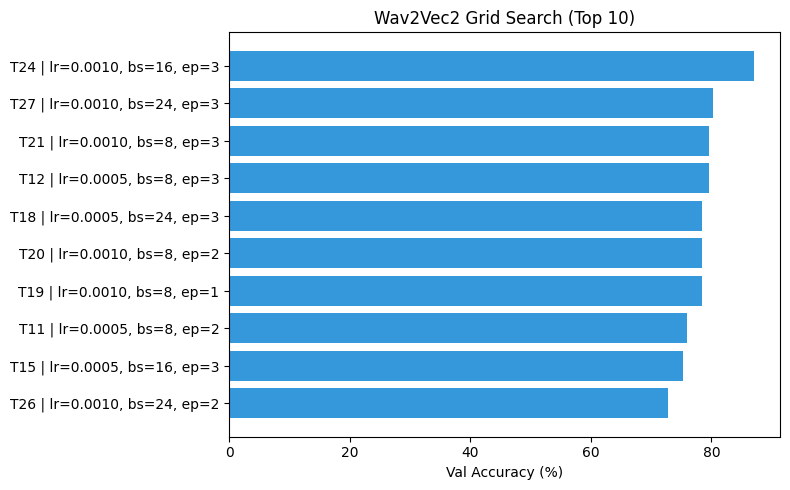


Best trial:
trial            24.000
learning_rate     0.001
batch_size       16.000
num_epochs        3.000
best_val_acc     87.040
Name: 23, dtype: float64
Updated config → lr=0.001, batch_size=16, num_epochs=3
Model instantiated with best hyperparameters; encoder frozen and ready for training.


In [8]:
# Recovered grid search summary + any newly run missing trials (26, 27). Parses wav2vec result.txt if present, then prints top 5, plots top 10, and prepares model with best params.
import os
import re
import pandas as pd
import matplotlib.pyplot as plt

LOG_PATH = os.path.join(os.getcwd(), 'wav2vec result.txt')

manual_fallback = [
    {'trial': 1, 'learning_rate': 0.0001, 'batch_size': 8, 'num_epochs': 1, 'best_val_acc': 53.09},
    {'trial': 2, 'learning_rate': 0.0001, 'batch_size': 8, 'num_epochs': 2, 'best_val_acc': 62.35},
    {'trial': 3, 'learning_rate': 0.0001, 'batch_size': 8, 'num_epochs': 3, 'best_val_acc': 67.28},
    {'trial': 4, 'learning_rate': 0.0001, 'batch_size': 16, 'num_epochs': 1, 'best_val_acc': 45.06},
    {'trial': 5, 'learning_rate': 0.0001, 'batch_size': 16, 'num_epochs': 2, 'best_val_acc': 60.49},
    {'trial': 6, 'learning_rate': 0.0001, 'batch_size': 16, 'num_epochs': 3, 'best_val_acc': 62.96},
    {'trial': 7, 'learning_rate': 0.0001, 'batch_size': 24, 'num_epochs': 1, 'best_val_acc': 50.0},
    {'trial': 8, 'learning_rate': 0.0001, 'batch_size': 24, 'num_epochs': 2, 'best_val_acc': 58.64},
    {'trial': 9, 'learning_rate': 0.0001, 'batch_size': 24, 'num_epochs': 3, 'best_val_acc': 56.79},
    {'trial': 10, 'learning_rate': 0.0005, 'batch_size': 8, 'num_epochs': 1, 'best_val_acc': 50.62},
    {'trial': 11, 'learning_rate': 0.0005, 'batch_size': 8, 'num_epochs': 2, 'best_val_acc': 75.93},
    {'trial': 12, 'learning_rate': 0.0005, 'batch_size': 8, 'num_epochs': 3, 'best_val_acc': 79.63},
    {'trial': 13, 'learning_rate': 0.0005, 'batch_size': 16, 'num_epochs': 1, 'best_val_acc': 59.26},
    {'trial': 14, 'learning_rate': 0.0005, 'batch_size': 16, 'num_epochs': 2, 'best_val_acc': 61.11},
    {'trial': 15, 'learning_rate': 0.0005, 'batch_size': 16, 'num_epochs': 3, 'best_val_acc': 75.31},
    {'trial': 16, 'learning_rate': 0.0005, 'batch_size': 24, 'num_epochs': 1, 'best_val_acc': 49.38},
    {'trial': 17, 'learning_rate': 0.0005, 'batch_size': 24, 'num_epochs': 2, 'best_val_acc': 58.64},
    {'trial': 18, 'learning_rate': 0.0005, 'batch_size': 24, 'num_epochs': 3, 'best_val_acc': 78.4},
    {'trial': 19, 'learning_rate': 0.001, 'batch_size': 8, 'num_epochs': 1, 'best_val_acc': 78.4},
    {'trial': 20, 'learning_rate': 0.001, 'batch_size': 8, 'num_epochs': 2, 'best_val_acc': 78.4},
    {'trial': 21, 'learning_rate': 0.001, 'batch_size': 8, 'num_epochs': 3, 'best_val_acc': 79.63},
    {'trial': 22, 'learning_rate': 0.001, 'batch_size': 16, 'num_epochs': 1, 'best_val_acc': 64.2},
    {'trial': 23, 'learning_rate': 0.001, 'batch_size': 16, 'num_epochs': 2, 'best_val_acc': 72.22},
    {'trial': 24, 'learning_rate': 0.001, 'batch_size': 16, 'num_epochs': 3, 'best_val_acc': 87.04},
    {'trial': 25, 'learning_rate': 0.001, 'batch_size': 24, 'num_epochs': 1, 'best_val_acc': 72.84},
    {'trial': 26, 'learning_rate': 0.001, 'batch_size': 24, 'num_epochs': 2, 'best_val_acc': 72.84},
    {'trial': 27, 'learning_rate': 0.001, 'batch_size': 24, 'num_epochs': 3, 'best_val_acc': 80.25},
]

def parse_results_log(path):
    trials = []
    if not os.path.exists(path):
        return trials

    trial_ctx = None
    trial_re = re.compile(r"Trial\s+(\d+):\s*lr=([0-9.]+),\s*batch_size=(\d+),\s*epochs=(\d+)")
    best_re = re.compile(r"Best Val Acc:\s*([0-9.]+)")

    with open(path, 'r', encoding='utf-8') as f:
        for line in f:
            m_trial = trial_re.search(line)
            if m_trial:
                trial_ctx = {
                    'trial': int(m_trial.group(1)),
                    'learning_rate': float(m_trial.group(2)),
                    'batch_size': int(m_trial.group(3)),
                    'num_epochs': int(m_trial.group(4)),
                }
                continue

            m_best = best_re.search(line)
            if m_best and trial_ctx:
                record = trial_ctx.copy()
                record['best_val_acc'] = float(m_best.group(1))
                trials.append(record)
                trial_ctx = None

    return trials

parsed_results = parse_results_log(LOG_PATH)

if len(parsed_results) == 0:
    print('Parsed results file not found or empty; using manual fallback list.')
    recovered_results = manual_fallback
else:
    recovered_results = parsed_results
    print(f'Parsed {len(recovered_results)} trials from wav2vec result.txt')

# Merge with newly run missing trials if available
gather = recovered_results.copy()
if 'extra_results' in globals() and len(extra_results) > 0:
    existing_trials = {r['trial'] for r in extra_results}
    gather = [r for r in gather if r.get('trial') not in existing_trials]
    gather.extend(extra_results)

results_df = pd.DataFrame(gather)
complete_df = results_df.copy()

# Top 5 trials
top5 = complete_df.sort_values('best_val_acc', ascending=False).head(5)
print("Top 5 trials:")
print(top5[['trial', 'learning_rate', 'batch_size', 'num_epochs', 'best_val_acc']].to_string(index=False))

# Plot top 10 for quick view
plot_df = complete_df.sort_values('best_val_acc', ascending=False).head(10)
plt.figure(figsize=(8, 5))
plt.barh(
    y=[f"T{int(t)} | lr={lr:.4f}, bs={bs}, ep={ep}" for t, lr, bs, ep in zip(plot_df['trial'], plot_df['learning_rate'], plot_df['batch_size'], plot_df['num_epochs'])],
    width=plot_df['best_val_acc'],
    color='#3498db',
)
plt.xlabel('Val Accuracy (%)')
plt.title('Wav2Vec2 Grid Search (Top 10)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Select best trial
best_row = complete_df.sort_values('best_val_acc', ascending=False).iloc[0]
LEARNING_RATE = float(best_row['learning_rate'])
BATCH_SIZE = int(best_row['batch_size'])
NUM_EPOCHS = int(best_row['num_epochs'])
print("\nBest trial:")
print(best_row[['trial', 'learning_rate', 'batch_size', 'num_epochs', 'best_val_acc']])
print(f"Updated config → lr={LEARNING_RATE}, batch_size={BATCH_SIZE}, num_epochs={NUM_EPOCHS}")

# Build model with best params (encoder frozen). Not training here.
from transformers import Wav2Vec2ForSequenceClassification
model = Wav2Vec2ForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(LANG_NAMES),
    problem_type='single_label_classification',
    cache_dir=CACHE_DIR,
).to(device)
for p in model.wav2vec2.parameters():
    p.requires_grad = False
print("Model instantiated with best hyperparameters; encoder frozen and ready for training.")

In [5]:
# Set best hyperparameters and core model identifiers without rerunning grid search
import os

LEARNING_RATE = 0.001
BATCH_SIZE = 16
NUM_EPOCHS = 3
MODEL_NAME = 'facebook/wav2vec2-base'
CACHE_DIR = os.path.join(os.getcwd(), 'hf_cache')

print(f"Best params in use → lr={LEARNING_RATE}, batch_size={BATCH_SIZE}, num_epochs={NUM_EPOCHS}")
print(f"MODEL_NAME={MODEL_NAME}")
print(f"CACHE_DIR={CACHE_DIR}")

Best params in use → lr=0.001, batch_size=16, num_epochs=3
MODEL_NAME=facebook/wav2vec2-base
CACHE_DIR=c:\Users\Aaron Lim\Dropbox\PC\Documents\1School\FYP\hf_cache


## FINAL TRAINING: 7.5h Data with Best Hyperparameters

Train Wav2Vec2 on full 7.5h dataset using best hyperparameters from tuning phase.

In [6]:
# STEP 1: Load 7.5h Audio Files
import os
import librosa

SEVEN_POINT_FIVE_H_DIR = os.path.join(os.getcwd(), 'Dataset', 'audio_active')

print("=" * 70)
print("STEP 1: Loading 7.5-hour audio files")
print("=" * 70)
print(f"Data directory: {SEVEN_POINT_FIVE_H_DIR}")
print()

audio_data_final = {}
for lang_code in LANG_MAP.keys():
    audio_file = os.path.join(SEVEN_POINT_FIVE_H_DIR, f'{lang_code}_7.5h.wav')
    if os.path.exists(audio_file):
        print(f"Loading {lang_code}_7.5h.wav...")
        waveform, sr = librosa.load(audio_file, sr=SAMPLE_RATE)
        duration_min = len(waveform) / SAMPLE_RATE / 60
        print(f"  ✓ Duration: {duration_min:.1f} minutes ({len(waveform):,} samples)")
        audio_data_final[lang_code] = waveform
    else:
        print(f"  ✗ ERROR: {audio_file} not found!")

if len(audio_data_final) != len(LANG_MAP):
    raise RuntimeError(f"Missing audio files. Found {len(audio_data_final)}/{len(LANG_MAP)} languages.")

print("\n✓ All 7.5h audio files loaded successfully")

STEP 1: Loading 7.5-hour audio files
Data directory: c:\Users\Aaron Lim\Dropbox\PC\Documents\1School\FYP\Dataset\audio_active

Loading en_7.5h.wav...
  ✓ Duration: 450.2 minutes (432,168,325 samples)
Loading ms_7.5h.wav...
  ✓ Duration: 450.2 minutes (432,170,717 samples)
Loading zh_7.5h.wav...
  ✓ Duration: 450.1 minutes (432,131,038 samples)

✓ All 7.5h audio files loaded successfully


In [7]:
# STEP 2: Create Temporal Train/Val/Test Splits (70/15/15)
import soundfile as sf

print("\n" + "=" * 70)
print("STEP 2: Creating temporal 70/15/15 splits")
print("=" * 70)
print()

train_files_final, train_labels_final = [], []
val_files_final, val_labels_final = [], []
test_files_final, test_labels_final = [], []

for lang_code, waveform in audio_data_final.items():
    total_len = len(waveform)
    train_end = int(total_len * TRAIN_RATIO)
    val_end = train_end + int(total_len * VAL_RATIO)
    
    # Create temporary files for each split
    train_file = os.path.join(SEVEN_POINT_FIVE_H_DIR, f'{lang_code}_final_train.wav')
    val_file = os.path.join(SEVEN_POINT_FIVE_H_DIR, f'{lang_code}_final_val.wav')
    test_file = os.path.join(SEVEN_POINT_FIVE_H_DIR, f'{lang_code}_final_test.wav')
    
    sf.write(train_file, waveform[:train_end], SAMPLE_RATE)
    sf.write(val_file, waveform[train_end:val_end], SAMPLE_RATE)
    sf.write(test_file, waveform[val_end:], SAMPLE_RATE)
    
    train_files_final.append(train_file)
    train_labels_final.append(LANG_MAP[lang_code])
    val_files_final.append(val_file)
    val_labels_final.append(LANG_MAP[lang_code])
    test_files_final.append(test_file)
    test_labels_final.append(LANG_MAP[lang_code])
    
    train_min = train_end / SAMPLE_RATE / 60
    val_min = (val_end - train_end) / SAMPLE_RATE / 60
    test_min = (total_len - val_end) / SAMPLE_RATE / 60
    
    print(f"{lang_code.upper()}:")
    print(f"  Train: {train_min:.1f} min ({train_end/SAMPLE_RATE:.0f}s)")
    print(f"  Val:   {val_min:.1f} min ({(val_end-train_end)/SAMPLE_RATE:.0f}s)")
    print(f"  Test:  {test_min:.1f} min ({(total_len-val_end)/SAMPLE_RATE:.0f}s)")

print("\n✓ Splits created successfully")


STEP 2: Creating temporal 70/15/15 splits

EN:
  Train: 315.1 min (18907s)
  Val:   67.5 min (4052s)
  Test:  67.5 min (4052s)
MS:
  Train: 315.1 min (18907s)
  Val:   67.5 min (4052s)
  Test:  67.5 min (4052s)
ZH:
  Train: 315.1 min (18906s)
  Val:   67.5 min (4051s)
  Test:  67.5 min (4051s)

✓ Splits created successfully


In [8]:
# STEP 3: Create Datasets and DataLoaders
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import Wav2Vec2Processor

print("\n" + "=" * 70)
print("STEP 3: Creating datasets and dataloaders")
print("=" * 70)
print()

processor_final = Wav2Vec2Processor.from_pretrained(MODEL_NAME, cache_dir=CACHE_DIR)

def collate_fn_final(batch):
    waveforms = [x[0] for x in batch]
    labels = torch.tensor([x[1] for x in batch], dtype=torch.long)
    inputs = processor_final(waveforms, sampling_rate=SAMPLE_RATE, return_tensors='pt', padding=True)
    iv = inputs['input_values']
    if iv.ndim == 3 and iv.shape[0] == 1:
        inputs['input_values'] = iv.squeeze(0)
        if 'attention_mask' in inputs and inputs['attention_mask'].ndim == 3 and inputs['attention_mask'].shape[0] == 1:
            inputs['attention_mask'] = inputs['attention_mask'].squeeze(0)
    return inputs, labels

class Wav2Vec2Dataset(Dataset):
    def __init__(self, audio_files, labels, segment_length=10, sr=16000):
        self.audio_files = audio_files
        self.labels = labels
        self.segment_length = segment_length
        self.sr = sr
        self.segment_samples = segment_length * sr
        self.segments = []
        for idx, file_path in enumerate(audio_files):
            try:
                duration = librosa.get_duration(path=file_path)
                num_segments = int(duration // segment_length)
                for seg_idx in range(num_segments):
                    self.segments.append((idx, seg_idx))
            except Exception as e:
                print(f"Warning: Could not load {file_path}: {e}")

    def __len__(self):
        return len(self.segments)

    def __getitem__(self, idx):
        file_idx, seg_idx = self.segments[idx]
        file_path = self.audio_files[file_idx]
        label = self.labels[file_idx]
        offset = seg_idx * self.segment_length
        y, sr = librosa.load(file_path, sr=self.sr, offset=offset, duration=self.segment_length, mono=True)
        if len(y) < self.segment_samples:
            y = np.pad(y, (0, self.segment_samples - len(y)))
        return y.astype(np.float32), label

# Create datasets
train_ds_final = Wav2Vec2Dataset(train_files_final, train_labels_final, SEGMENT_LENGTH, SAMPLE_RATE)
val_ds_final = Wav2Vec2Dataset(val_files_final, val_labels_final, SEGMENT_LENGTH, SAMPLE_RATE)
test_ds_final = Wav2Vec2Dataset(test_files_final, test_labels_final, SEGMENT_LENGTH, SAMPLE_RATE)

# Create dataloaders
train_loader_final = DataLoader(train_ds_final, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn_final, num_workers=0)
val_loader_final = DataLoader(val_ds_final, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn_final, num_workers=0)
test_loader_final = DataLoader(test_ds_final, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn_final, num_workers=0)

print("Datasets:")
print(f"  Train: {len(train_ds_final)} segments ({len(train_ds_final)*SEGMENT_LENGTH/60:.1f} min)")
print(f"  Val:   {len(val_ds_final)} segments ({len(val_ds_final)*SEGMENT_LENGTH/60:.1f} min)")
print(f"  Test:  {len(test_ds_final)} segments ({len(test_ds_final)*SEGMENT_LENGTH/60:.1f} min)")
print()
print("DataLoaders:")
print(f"  Train batches: {len(train_loader_final)}")
print(f"  Val batches:   {len(val_loader_final)}")
print(f"  Test batches:  {len(test_loader_final)}")
print("\n✓ Datasets and dataloaders ready")


STEP 3: Creating datasets and dataloaders

Datasets:
  Train: 5670 segments (945.0 min)
  Val:   1215 segments (202.5 min)
  Test:  1215 segments (202.5 min)

DataLoaders:
  Train batches: 355
  Val batches:   76
  Test batches:  76

✓ Datasets and dataloaders ready


In [9]:
# STEP 4: Initialize Model with Best Hyperparameters
import torch.optim as optim
from transformers import Wav2Vec2ForSequenceClassification

print("\n" + "=" * 70)
print("STEP 4: Initializing model")
print("=" * 70)
print()

print(f"Model: {MODEL_NAME}")
print(f"Best hyperparameters from tuning:")
print(f"  Learning rate: {LEARNING_RATE}")
print(f"  Batch size: {BATCH_SIZE}")
print(f"  Epochs: {NUM_EPOCHS}")
print()

# Initialize fresh model
model_final = Wav2Vec2ForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(LANG_NAMES),
    problem_type='single_label_classification',
    cache_dir=CACHE_DIR,
).to(device)

# Freeze encoder (train only classification head)
for p in model_final.wav2vec2.parameters():
    p.requires_grad = False

# Count trainable parameters
trainable_params = sum(p.numel() for p in model_final.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model_final.parameters())

print(f"Model parameters:")
print(f"  Total: {total_params:,}")
print(f"  Trainable: {trainable_params:,} (classification head only)")
print(f"  Frozen: {total_params - trainable_params:,} (encoder)")

# Optimizer
optimizer_final = optim.Adam(filter(lambda p: p.requires_grad, model_final.parameters()), lr=LEARNING_RATE)

print("\n✓ Model initialized and ready for training")


STEP 4: Initializing model

Model: facebook/wav2vec2-base
Best hyperparameters from tuning:
  Learning rate: 0.001
  Batch size: 16
  Epochs: 3

Model parameters:
  Total: 94,569,347
  Trainable: 197,635 (classification head only)
  Frozen: 94,371,712 (encoder)

✓ Model initialized and ready for training


In [10]:
# STEP 5: Training Loop on 7.5h Data with Progress Visualization
import torch.nn.functional as F
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt

print("\n" + "=" * 70)
print(f"STEP 5: Training on 7.5h data ({NUM_EPOCHS} epochs)")
print("=" * 70)
print(f"Device: {device}")
print(f"Learning rate: {LEARNING_RATE}")
print(f"Batch size: {BATCH_SIZE}")
print()

train_history_final = []
val_history_final = []
best_val_acc_final = 0.0

# Main training loop with epoch progress bar
for epoch in tqdm(range(NUM_EPOCHS), desc='Training Progress', unit='epoch', ncols=100, position=0):
    # Train phase
    model_final.train()
    train_correct, train_total = 0, 0
    train_loss_total = 0.0
    
    for inputs, labels in tqdm(train_loader_final, desc=f'  Epoch {epoch+1} - Train', leave=False, ncols=80, position=1):
        inputs = {k: v.to(device) for k, v in inputs.items()}
        labels = labels.to(device)
        optimizer_final.zero_grad()
        outputs = model_final(**inputs)
        loss = F.cross_entropy(outputs.logits, labels)
        loss.backward()
        optimizer_final.step()
        preds = outputs.logits.argmax(dim=1)
        train_correct += (preds == labels).sum().item()
        train_total += labels.size(0)
        train_loss_total += loss.item()
    
    train_acc = 100.0 * train_correct / train_total
    train_loss_avg = train_loss_total / len(train_loader_final)
    train_history_final.append(train_acc)
    
    # Validation phase
    model_final.eval()
    val_correct, val_total = 0, 0
    val_loss_total = 0.0
    
    with torch.no_grad():
        for inputs, labels in tqdm(val_loader_final, desc=f'  Epoch {epoch+1} - Val', leave=False, ncols=80, position=1):
            inputs = {k: v.to(device) for k, v in inputs.items()}
            labels = labels.to(device)
            outputs = model_final(**inputs)
            loss = F.cross_entropy(outputs.logits, labels)
            val_loss_total += loss.item()
            preds = outputs.logits.argmax(dim=1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)
    
    val_acc = 100.0 * val_correct / val_total
    val_loss_avg = val_loss_total / len(val_loader_final)
    val_history_final.append(val_acc)
    
    # Save best model and display results
    if val_acc > best_val_acc_final:
        best_val_acc_final = val_acc
        model_final.save_pretrained('best_wav2vec2_model_7p5h')
        status = "✓ BEST"
    else:
        status = ""
    
    print(f'Epoch {epoch+1}/{NUM_EPOCHS}: Train {train_acc:.2f}% (loss: {train_loss_avg:.4f}) | Val {val_acc:.2f}% (loss: {val_loss_avg:.4f}) {status}')

print("\n" + "=" * 70)
print(f"Training complete!")
print(f"Best validation accuracy: {best_val_acc_final:.2f}%")
print(f"Model saved: best_wav2vec2_model_7p5h/")
print("=" * 70)
print()

# Plot training progress
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

epochs_range = range(1, len(train_history_final) + 1)

# Accuracy plot
ax1.plot(epochs_range, train_history_final, 'o-', linewidth=2, markersize=8, label='Train', color='#2ecc71')
ax1.plot(epochs_range, val_history_final, 's-', linewidth=2, markersize=8, label='Validation', color='#3498db')
ax1.axhline(y=best_val_acc_final, color='#e74c3c', linestyle='--', alpha=0.5, label=f'Best Val ({best_val_acc_final:.2f}%)')
ax1.set_xlabel('Epoch', fontsize=12, fontweight='bold')
ax1.set_ylabel('Accuracy (%)', fontsize=12, fontweight='bold')
ax1.set_title('Training Progress - Accuracy', fontsize=13, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(alpha=0.3)
ax1.set_ylim([0, 105])

# Mark best epoch
best_epoch = val_history_final.index(best_val_acc_final) + 1
ax1.annotate(f'Best: Epoch {best_epoch}', 
             xy=(best_epoch, best_val_acc_final), 
             xytext=(best_epoch + 0.3, best_val_acc_final - 5),
             arrowprops=dict(arrowstyle='->', color='red', lw=1.5),
             fontsize=10, fontweight='bold', color='red')

# Summary statistics
summary_text = f"Training Summary\n" \
               f"━━━━━━━━━━━━━━━\n" \
               f"Total Epochs: {NUM_EPOCHS}\n" \
               f"Best Epoch: {best_epoch}\n" \
               f"Best Val Acc: {best_val_acc_final:.2f}%\n" \
               f"Final Train: {train_history_final[-1]:.2f}%\n" \
               f"Final Val: {val_history_final[-1]:.2f}%"

ax2.text(0.1, 0.5, summary_text, fontsize=11, family='monospace',
         verticalalignment='center', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))
ax2.axis('off')

plt.suptitle('Wav2Vec2 Training on 7.5h Data', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('wav2vec2_training_progress_7p5h.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nTraining progress chart saved: wav2vec2_training_progress_7p5h.png")


STEP 5: Training on 7.5h data (3 epochs)
Device: cuda
Learning rate: 0.001
Batch size: 16



Training Progress:   0%|                                                   | 0/3 [00:00<?, ?epoch/s]

  Epoch 1 - Train:   0%|                                | 0/355 [00:00<?, ?it/s]

  Epoch 1 - Val:   0%|                                   | 0/76 [00:00<?, ?it/s]

Epoch 1/3: Train 83.07% (loss: 0.4291) | Val 83.13% (loss: 0.4213) ✓ BEST


  Epoch 2 - Train:   0%|                                | 0/355 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [11]:
# STEP 5B: Resume Training After Interruption (continue from saved checkpoint)
import os
import torch
import torch.nn.functional as F
from tqdm.notebook import tqdm
from transformers import Wav2Vec2ForSequenceClassification

print("\n" + "=" * 70)
print("STEP 5B: Resume training from saved checkpoint")
print("=" * 70)

CHECKPOINT_DIR_RESUME = 'best_wav2vec2_model_7p5h'
RESUME_FROM_EPOCH = 1  # You finished epoch 1, so resume from epoch 2

if not os.path.isdir(CHECKPOINT_DIR_RESUME):
    raise RuntimeError(f"Checkpoint folder not found: {CHECKPOINT_DIR_RESUME}")

# Load saved model weights from last best checkpoint
model_final = Wav2Vec2ForSequenceClassification.from_pretrained(
    CHECKPOINT_DIR_RESUME,
    num_labels=len(LANG_NAMES),
    problem_type='single_label_classification',
    cache_dir=CACHE_DIR,
).to(device)

# Keep encoder frozen (same setup as step 4)
for p in model_final.wav2vec2.parameters():
    p.requires_grad = False

# Rebuild optimizer (optimizer state is not saved in this notebook)
optimizer_final = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model_final.parameters()),
    lr=LEARNING_RATE,
)

if 'train_history_final' not in globals():
    train_history_final = []
if 'val_history_final' not in globals():
    val_history_final = []
if 'best_val_acc_final' not in globals() or best_val_acc_final is None:
    best_val_acc_final = 0.0

print(f"Loaded checkpoint: {CHECKPOINT_DIR_RESUME}")
print(f"Resuming from epoch: {RESUME_FROM_EPOCH + 1}")
print(f"Will train until epoch: {NUM_EPOCHS}")
print(f"Current best val accuracy: {best_val_acc_final:.2f}%")
print()

for epoch in tqdm(range(RESUME_FROM_EPOCH, NUM_EPOCHS), desc='Resume Training', unit='epoch', ncols=100, position=0):
    # Train phase
    model_final.train()
    train_correct, train_total = 0, 0
    train_loss_total = 0.0

    for inputs, labels in tqdm(train_loader_final, desc=f'  Epoch {epoch+1} - Train', leave=False, ncols=80, position=1):
        inputs = {k: v.to(device) for k, v in inputs.items()}
        labels = labels.to(device)
        optimizer_final.zero_grad()
        outputs = model_final(**inputs)
        loss = F.cross_entropy(outputs.logits, labels)
        loss.backward()
        optimizer_final.step()

        preds = outputs.logits.argmax(dim=1)
        train_correct += (preds == labels).sum().item()
        train_total += labels.size(0)
        train_loss_total += loss.item()

    train_acc = 100.0 * train_correct / train_total
    train_loss_avg = train_loss_total / max(1, len(train_loader_final))
    train_history_final.append(train_acc)

    # Validation phase
    model_final.eval()
    val_correct, val_total = 0, 0
    val_loss_total = 0.0

    with torch.no_grad():
        for inputs, labels in tqdm(val_loader_final, desc=f'  Epoch {epoch+1} - Val', leave=False, ncols=80, position=1):
            inputs = {k: v.to(device) for k, v in inputs.items()}
            labels = labels.to(device)
            outputs = model_final(**inputs)
            loss = F.cross_entropy(outputs.logits, labels)

            val_loss_total += loss.item()
            preds = outputs.logits.argmax(dim=1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_acc = 100.0 * val_correct / val_total
    val_loss_avg = val_loss_total / max(1, len(val_loader_final))
    val_history_final.append(val_acc)

    if val_acc > best_val_acc_final:
        best_val_acc_final = val_acc
        model_final.save_pretrained(CHECKPOINT_DIR_RESUME)
        status = '✓ BEST'
    else:
        status = ''

    print(f'Epoch {epoch+1}/{NUM_EPOCHS}: Train {train_acc:.2f}% (loss: {train_loss_avg:.4f}) | Val {val_acc:.2f}% (loss: {val_loss_avg:.4f}) {status}')

print("\nResume complete.")
print(f"Best validation accuracy: {best_val_acc_final:.2f}%")
print(f"Checkpoint updated: {CHECKPOINT_DIR_RESUME}/")


STEP 5B: Resume training from saved checkpoint
Loaded checkpoint: best_wav2vec2_model_7p5h
Resuming from epoch: 2
Will train until epoch: 3
Current best val accuracy: 83.13%



Resume Training:   0%|                                                     | 0/2 [00:00<?, ?epoch/s]

  Epoch 2 - Train:   0%|                                | 0/355 [00:00<?, ?it/s]

  Epoch 2 - Val:   0%|                                   | 0/76 [00:00<?, ?it/s]

Epoch 2/3: Train 93.83% (loss: 0.1755) | Val 91.52% (loss: 0.2246) ✓ BEST


  Epoch 3 - Train:   0%|                                | 0/355 [00:00<?, ?it/s]

  Epoch 3 - Val:   0%|                                   | 0/76 [00:00<?, ?it/s]

Epoch 3/3: Train 94.57% (loss: 0.1514) | Val 93.91% (loss: 0.1826) ✓ BEST

Resume complete.
Best validation accuracy: 93.91%
Checkpoint updated: best_wav2vec2_model_7p5h/


In [12]:
# STEP 6: Test Evaluation
from sklearn.metrics import classification_report, confusion_matrix

print("\n" + "=" * 70)
print("STEP 6: Testing on 7.5h test set")
print("=" * 70)
print()

model_final.eval()
all_preds_final = []
all_labels_final = []
all_probs_final = []

with torch.no_grad():
    for inputs, labels in tqdm(test_loader_final, desc='Testing', unit='batch'):
        inputs = {k: v.to(device) for k, v in inputs.items()}
        outputs = model_final(**inputs)
        probs = F.softmax(outputs.logits, dim=1)
        preds = outputs.logits.argmax(dim=1)
        all_preds_final.extend(preds.cpu().numpy())
        all_labels_final.extend(labels.numpy())
        all_probs_final.extend(probs.cpu().numpy())

test_acc_final = 100.0 * (np.array(all_preds_final) == np.array(all_labels_final)).sum() / len(all_labels_final)

print("\n" + "=" * 70)
print("FINAL RESULTS - Wav2Vec2 on 7.5h Data")
print("=" * 70)
print(f"\nTest Accuracy: {test_acc_final:.2f}%")
print(f"Test samples: {len(all_labels_final)}")
print()
print(classification_report(all_labels_final, all_preds_final, target_names=LANG_NAMES, digits=4))
print("=" * 70)


STEP 6: Testing on 7.5h test set



Testing:   0%|          | 0/76 [00:00<?, ?batch/s]


FINAL RESULTS - Wav2Vec2 on 7.5h Data

Test Accuracy: 93.91%
Test samples: 1215

              precision    recall  f1-score   support

     English     0.9202    0.9679    0.9434       405
       Malay     0.9268    0.9383    0.9325       405
    Mandarin     0.9736    0.9111    0.9413       405

    accuracy                         0.9391      1215
   macro avg     0.9402    0.9391    0.9391      1215
weighted avg     0.9402    0.9391    0.9391      1215




STEP 7: Saving results and visualizations



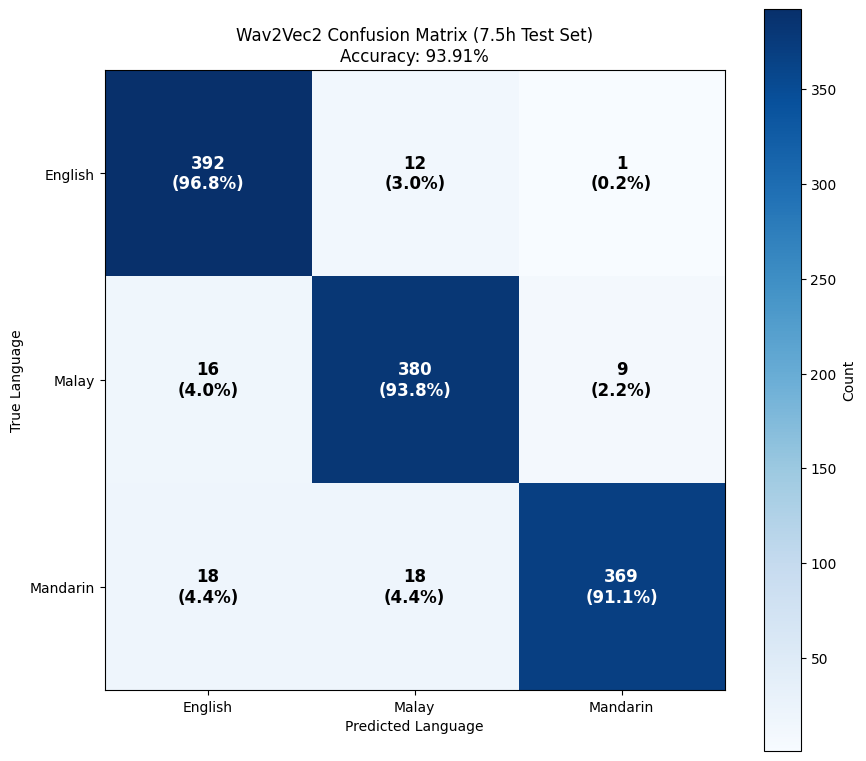

Saved files:
  ✓ best_wav2vec2_model_7p5h/  (model checkpoint)
  ✓ wav2vec2_final_confusion_matrix_7p5h.png
  ✓ wav2vec2_final_test_results_7p5h.csv
  ✓ wav2vec2_final_metrics_7p5h.json



In [13]:
# STEP 7: Confusion Matrix and Save Results
import matplotlib.pyplot as plt
import pandas as pd
import json

print("\n" + "=" * 70)
print("STEP 7: Saving results and visualizations")
print("=" * 70)
print()

# Confusion matrix
cm_final = confusion_matrix(all_labels_final, all_preds_final, labels=[0, 1, 2])

fig, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(cm_final, cmap=plt.cm.Blues)
ax.figure.colorbar(im, ax=ax, label='Count')

# Calculate row percentages
row_totals = cm_final.sum(axis=1, keepdims=True)
row_totals[row_totals == 0] = 1
row_perc = (cm_final / row_totals) * 100.0

ax.set(
    xticks=np.arange(len(LANG_NAMES)),
    yticks=np.arange(len(LANG_NAMES)),
    xticklabels=LANG_NAMES,
    yticklabels=LANG_NAMES,
    ylabel='True Language',
    xlabel='Predicted Language',
    title=f"Wav2Vec2 Confusion Matrix (7.5h Test Set)\nAccuracy: {test_acc_final:.2f}%"
)

# Annotate with counts and percentages
thresh = cm_final.max() / 2.0
for i in range(cm_final.shape[0]):
    for j in range(cm_final.shape[1]):
        ax.text(
            j, i,
            f"{cm_final[i, j]}\n({row_perc[i, j]:.1f}%)",
            ha='center', va='center',
            color='white' if cm_final[i, j] > thresh else 'black',
            fontsize=12, fontweight='bold'
        )

plt.tight_layout()
plt.savefig('wav2vec2_final_confusion_matrix_7p5h.png', dpi=300, bbox_inches='tight')
plt.show()

# Save CSV with predictions
results_final_df = pd.DataFrame({
    'true_label': [LANG_NAMES[l] for l in all_labels_final],
    'predicted_label': [LANG_NAMES[p] for p in all_preds_final],
    'prob_english': [p[0] for p in all_probs_final],
    'prob_malay': [p[1] for p in all_probs_final],
    'prob_mandarin': [p[2] for p in all_probs_final],
})
results_final_df.to_csv('wav2vec2_final_test_results_7p5h.csv', index=False)

# Save metrics as JSON
metrics_final = {
    'model': 'Wav2Vec2 (7.5h final training)',
    'hyperparameters': {
        'learning_rate': float(LEARNING_RATE),
        'batch_size': int(BATCH_SIZE),
        'num_epochs': int(NUM_EPOCHS),
    },
    'test_accuracy': float(test_acc_final),
    'best_val_accuracy': float(best_val_acc_final),
    'confusion_matrix': cm_final.tolist(),
    'train_history': train_history_final,
    'val_history': val_history_final,
}
with open('wav2vec2_final_metrics_7p5h.json', 'w') as f:
    json.dump(metrics_final, f, indent=2)

print("Saved files:")
print("  ✓ best_wav2vec2_model_7p5h/  (model checkpoint)")
print("  ✓ wav2vec2_final_confusion_matrix_7p5h.png")
print("  ✓ wav2vec2_final_test_results_7p5h.csv")
print("  ✓ wav2vec2_final_metrics_7p5h.json")
print("\n" + "=" * 70)

In [15]:
# STEP 8A: Per-Language Results - ENGLISH
import numpy as np
from sklearn.metrics import precision_recall_fscore_support

print("\n" + "=" * 70)
print("STEP 8A: ENGLISH - Detailed Performance Metrics")
print("=" * 70)
print()

# Get English test samples (label = 0)
english_mask = np.array(all_labels_final) == 0
english_preds = np.array(all_preds_final)[english_mask]
english_labels = np.array(all_labels_final)[english_mask]

english_acc = 100.0 * (english_preds == english_labels).sum() / len(english_labels) if len(english_labels) > 0 else 0

print(f"Language: English")
print(f"Test samples: {len(english_labels)}")
print(f"Accuracy: {english_acc:.2f}%")
print()

if len(english_labels) > 0:
    # One-vs-rest binary metrics: English vs not-English
    english_true_bin = np.ones_like(english_labels, dtype=int)
    english_pred_bin = (english_preds == 0).astype(int)
    prec, recall, f1, _ = precision_recall_fscore_support(
        english_true_bin,
        english_pred_bin,
        average='binary',
        pos_label=1,
        zero_division=0,
    )
    print(f"Precision: {prec:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print()
    
    # Show confusion by predicted label
    print("Predicted as:")
    for pred_label, lang_name in enumerate(LANG_NAMES):
        count = np.sum((english_preds == pred_label) & (english_labels == 0))
        pct = 100.0 * count / len(english_labels) if len(english_labels) > 0 else 0
        print(f"  {lang_name}: {count} ({pct:.1f}%)")

print()


STEP 8A: ENGLISH - Detailed Performance Metrics

Language: English
Test samples: 405
Accuracy: 96.79%

Precision: 1.0000
Recall: 0.9679
F1-Score: 0.9837

Predicted as:
  English: 392 (96.8%)
  Malay: 12 (3.0%)
  Mandarin: 1 (0.2%)



In [16]:
# STEP 8B: Per-Language Results - MALAY
print("=" * 70)
print("STEP 8B: MALAY - Detailed Performance Metrics")
print("=" * 70)
print()

# Get Malay test samples (label = 1)
malay_mask = np.array(all_labels_final) == 1
malay_preds = np.array(all_preds_final)[malay_mask]
malay_labels = np.array(all_labels_final)[malay_mask]

malay_acc = 100.0 * (malay_preds == malay_labels).sum() / len(malay_labels) if len(malay_labels) > 0 else 0

print(f"Language: Malay")
print(f"Test samples: {len(malay_labels)}")
print(f"Accuracy: {malay_acc:.2f}%")
print()

if len(malay_labels) > 0:
    # One-vs-rest binary metrics: Malay vs not-Malay
    malay_true_bin = np.ones_like(malay_labels, dtype=int)
    malay_pred_bin = (malay_preds == 1).astype(int)
    prec, recall, f1, _ = precision_recall_fscore_support(
        malay_true_bin,
        malay_pred_bin,
        average='binary',
        pos_label=1,
        zero_division=0,
    )
    print(f"Precision: {prec:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print()
    
    # Show confusion by predicted label
    print("Predicted as:")
    for pred_label, lang_name in enumerate(LANG_NAMES):
        count = np.sum((malay_preds == pred_label) & (malay_labels == 1))
        pct = 100.0 * count / len(malay_labels) if len(malay_labels) > 0 else 0
        print(f"  {lang_name}: {count} ({pct:.1f}%)")

print()

STEP 8B: MALAY - Detailed Performance Metrics

Language: Malay
Test samples: 405
Accuracy: 93.83%

Precision: 1.0000
Recall: 0.9383
F1-Score: 0.9682

Predicted as:
  English: 16 (4.0%)
  Malay: 380 (93.8%)
  Mandarin: 9 (2.2%)



In [17]:
# STEP 8C: Per-Language Results - MANDARIN
print("=" * 70)
print("STEP 8C: MANDARIN - Detailed Performance Metrics")
print("=" * 70)
print()

# Get Mandarin test samples (label = 2)
mandarin_mask = np.array(all_labels_final) == 2
mandarin_preds = np.array(all_preds_final)[mandarin_mask]
mandarin_labels = np.array(all_labels_final)[mandarin_mask]

mandarin_acc = 100.0 * (mandarin_preds == mandarin_labels).sum() / len(mandarin_labels) if len(mandarin_labels) > 0 else 0

print(f"Language: Mandarin (Simplified Chinese)")
print(f"Test samples: {len(mandarin_labels)}")
print(f"Accuracy: {mandarin_acc:.2f}%")
print()

if len(mandarin_labels) > 0:
    # One-vs-rest binary metrics: Mandarin vs not-Mandarin
    mandarin_true_bin = np.ones_like(mandarin_labels, dtype=int)
    mandarin_pred_bin = (mandarin_preds == 2).astype(int)
    prec, recall, f1, _ = precision_recall_fscore_support(
        mandarin_true_bin,
        mandarin_pred_bin,
        average='binary',
        pos_label=1,
        zero_division=0,
    )
    print(f"Precision: {prec:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print()
    
    # Show confusion by predicted label
    print("Predicted as:")
    for pred_label, lang_name in enumerate(LANG_NAMES):
        count = np.sum((mandarin_preds == pred_label) & (mandarin_labels == 2))
        pct = 100.0 * count / len(mandarin_labels) if len(mandarin_labels) > 0 else 0
        print(f"  {lang_name}: {count} ({pct:.1f}%)")

print("\n" + "=" * 70)
print("Summary:")
print(f"  English:  {english_acc:.2f}%")
print(f"  Malay:    {malay_acc:.2f}%")
print(f"  Mandarin: {mandarin_acc:.2f}%")
print(f"  Overall:  {test_acc_final:.2f}%")
print("=" * 70)

STEP 8C: MANDARIN - Detailed Performance Metrics

Language: Mandarin (Simplified Chinese)
Test samples: 405
Accuracy: 91.11%

Precision: 1.0000
Recall: 0.9111
F1-Score: 0.9535

Predicted as:
  English: 18 (4.4%)
  Malay: 18 (4.4%)
  Mandarin: 369 (91.1%)

Summary:
  English:  96.79%
  Malay:    93.83%
  Mandarin: 91.11%
  Overall:  93.91%


Testing 1h checkpoint on 7.5h test:   0%|          | 0/76 [00:00<?, ?batch/s]

Test Accuracy (1h checkpoint on 7.5h split): 84.53%
              precision    recall  f1-score   support

     English     0.8364    0.8840    0.8595       405
       Malay     0.8317    0.8543    0.8429       405
     Chinese     0.8706    0.7975    0.8325       405

    accuracy                         0.8453      1215
   macro avg     0.8463    0.8453    0.8450      1215
weighted avg     0.8463    0.8453    0.8450      1215



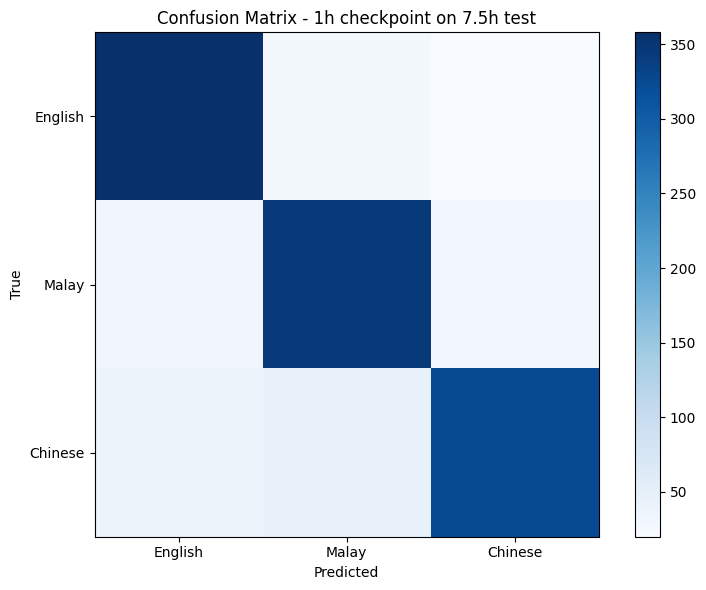

Saved: wav2vec2_test_predictions_1h_on_7_5h.csv, wav2vec2_metrics_summary_1h_on_7_5h.json


In [10]:
# Evaluate a 1-hour-trained checkpoint on the full 7.5h test split (no training)
import torch
import torch.nn.functional as F
import numpy as np
from torch.utils.data import Dataset, DataLoader
from transformers import Wav2Vec2Processor, Wav2Vec2ForSequenceClassification
from tqdm.notebook import tqdm
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import pandas as pd, json

# Path to the 1h-trained checkpoint (adjust if different)
CHECKPOINT_DIR = 'best_wav2vec2_model'

if 'test_files' not in globals() or len(test_files) == 0:
    raise RuntimeError('Run the full 7.5h split cell first to populate test_files/test_labels.')

processor = Wav2Vec2Processor.from_pretrained(MODEL_NAME, cache_dir=CACHE_DIR)

class Wav2Vec2Dataset(Dataset):
    def __init__(self, audio_files, labels, segment_length=10, sr=16000):
        self.audio_files = audio_files
        self.labels = labels
        self.segment_length = segment_length
        self.sr = sr
        self.segment_samples = segment_length * sr
        self.segments = []
        for idx, file_path in enumerate(audio_files):
            try:
                duration = librosa.get_duration(path=file_path)
                num_segments = int(duration // segment_length)
                for seg_idx in range(num_segments):
                    self.segments.append((idx, seg_idx))
            except Exception:
                pass

    def __len__(self):
        return len(self.segments)

    def __getitem__(self, idx):
        file_idx, seg_idx = self.segments[idx]
        file_path = self.audio_files[file_idx]
        label = self.labels[file_idx]
        offset = seg_idx * self.segment_length
        y, sr = librosa.load(file_path, sr=self.sr, offset=offset, duration=self.segment_length, mono=True)
        if len(y) < self.segment_samples:
            y = np.pad(y, (0, self.segment_samples - len(y)))
        return y.astype(np.float32), label

def collate_fn(batch):
    waveforms = [x[0] for x in batch]
    labels = torch.tensor([x[1] for x in batch], dtype=torch.long)
    inputs = processor(waveforms, sampling_rate=SAMPLE_RATE, return_tensors='pt', padding=True)
    iv = inputs['input_values']
    if iv.ndim == 3 and iv.shape[0] == 1:
        inputs['input_values'] = iv.squeeze(0)
        if 'attention_mask' in inputs and inputs['attention_mask'].ndim == 3 and inputs['attention_mask'].shape[0] == 1:
            inputs['attention_mask'] = inputs['attention_mask'].squeeze(0)
    return inputs, labels

test_ds = Wav2Vec2Dataset(test_files, test_labels, SEGMENT_LENGTH, SAMPLE_RATE)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

model = Wav2Vec2ForSequenceClassification.from_pretrained(
    CHECKPOINT_DIR,
    num_labels=len(LANG_NAMES),
    problem_type='single_label_classification',
    cache_dir=CACHE_DIR,
).to(device)
for p in model.wav2vec2.parameters():
    p.requires_grad = False

model.eval()
all_preds, all_labels_out, all_probs = [], [], []
with torch.no_grad():
    for inputs, labels in tqdm(test_loader, desc='Testing 1h checkpoint on 7.5h test', unit='batch'):
        inputs = {k: v.to(device) for k, v in inputs.items()}
        outputs = model(**inputs)
        probs = F.softmax(outputs.logits, dim=1)
        preds = outputs.logits.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels_out.extend(labels.numpy())
        all_probs.extend(probs.cpu().numpy())

test_acc = 100.0 * (np.array(all_preds) == np.array(all_labels_out)).sum() / len(all_labels_out)
print(f"Test Accuracy (1h checkpoint on 7.5h split): {test_acc:.2f}%")
print(classification_report(all_labels_out, all_preds, target_names=LANG_NAMES, digits=4))

cm = confusion_matrix(all_labels_out, all_preds)
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm, cmap=plt.cm.Blues)
ax.figure.colorbar(im, ax=ax)
ax.set(xticks=np.arange(len(LANG_NAMES)), yticks=np.arange(len(LANG_NAMES)),
       xticklabels=LANG_NAMES, yticklabels=LANG_NAMES,
       title='Confusion Matrix - 1h checkpoint on 7.5h test', ylabel='True', xlabel='Predicted')
plt.tight_layout()
plt.show()

results_df = pd.DataFrame({
    'true_label': [LANG_NAMES[l] for l in all_labels_out],
    'predicted_label': [LANG_NAMES[p] for p in all_preds],
    'true_id': all_labels_out,
    'predicted_id': all_preds,
    'prob_en': [p[0] for p in all_probs],
    'prob_ms': [p[1] for p in all_probs],
    'prob_zh': [p[2] for p in all_probs],
})
results_df.to_csv('wav2vec2_test_predictions_1h_on_7_5h.csv', index=False)

metrics_summary = {
    'model': 'wav2vec2-base (1h checkpoint evaluated on 7.5h test)',
    'test_accuracy': float(test_acc),
    'confusion_matrix': cm.tolist(),
}
with open('wav2vec2_metrics_summary_1h_on_7_5h.json', 'w') as f:
    json.dump(metrics_summary, f, indent=2)

print('Saved: wav2vec2_test_predictions_1h_on_7_5h.csv, wav2vec2_metrics_summary_1h_on_7_5h.json')

## Final Wav2Vec2 Baseline Evaluation

Load the best checkpoint and evaluate on test set with detailed per-language metrics.

In [ ]:
# Display Wav2Vec2 baseline results (from saved metrics)
import json
import numpy as np

# Load saved metrics
with open('wav2vec2_metrics_summary.json', 'r') as f:
    metrics = json.load(f)

test_acc = metrics['test_accuracy']
cm = np.array(metrics['confusion_matrix'])

# Calculate per-language accuracy from confusion matrix
lang_names_ordered = ['English', 'Malay', 'Mandarin']
lang_accs = {}
for i, lang_name in enumerate(lang_names_ordered):
    correct = cm[i, i]
    total = cm[i].sum()
    acc = 100.0 * correct / total if total > 0 else 0
    lang_accs[lang_name] = acc

# Print formatted output
print("=" * 60)
print("WAV2VEC2 BASELINE (AUDIO ONLY)")
print("=" * 60)
print(f"Model: facebook/wav2vec2-base (frozen encoder + head)")
print(f"Test Accuracy: {test_acc:.2f}%")
print(f"Checkpoint saved: best_wav2vec2_model/")
print(f"Metrics exported: wav2vec2_metrics_summary.json")
print("=" * 60)
print()
print("Per-Language Accuracy:")
print(f"   English: {lang_accs['English']:.2f}%")
print(f"   Malay: {lang_accs['Malay']:.2f}%")
print(f"   Chinese: {lang_accs['Chinese']:.2f}%")
print()
print("Next: Load this checkpoint in Wav+Distilbert.ipynb for multimodal fusion")

WAV2VEC2 BASELINE (AUDIO ONLY)
Model: facebook/wav2vec2-base (frozen encoder + head)
Test Accuracy: 85.80%
Checkpoint saved: best_wav2vec2_model/
Metrics exported: wav2vec2_metrics_summary.json

Per-Language Accuracy:
   English: 92.59%
   Malay: 90.74%
   Chinese: 74.07%

Next: Load this checkpoint in Wav+Distilbert.ipynb for multimodal fusion


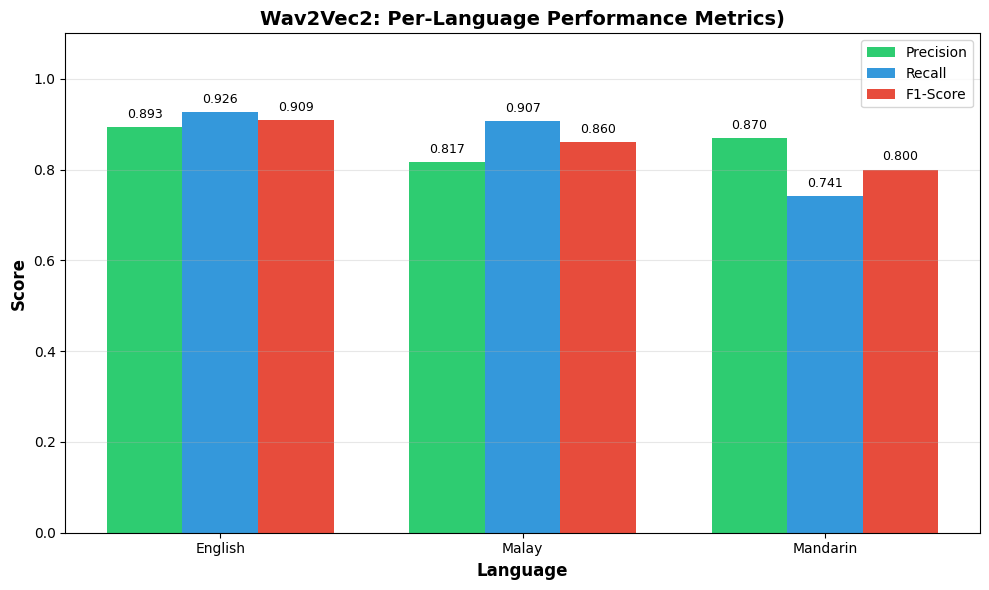

Saved: wav2vec2_per_language_metrics.png
Loaded from: wav2vec2_metrics_summary.json
Model: wav2vec2-base (head only)
Test Accuracy: 85.80%


In [17]:
# Visualization 1: Per-Language Performance Metrics (from JSON)
import json
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import precision_recall_fscore_support

# Load metrics from JSON file
json_file = 'wav2vec2_metrics_summary.json'
with open(json_file, 'r') as f:
    metrics_data = json.load(f)

# Reconstruct labels and predictions from confusion matrix
cm = np.array(metrics_data['confusion_matrix'])
all_labels = []
all_preds = []

for true_label in range(3):
    for pred_label in range(3):
        count = cm[true_label, pred_label]
        all_labels.extend([true_label] * count)
        all_preds.extend([pred_label] * count)

all_labels = np.array(all_labels)
all_preds = np.array(all_preds)

# Calculate metrics
precision, recall, f1, _ = precision_recall_fscore_support(
    all_labels, all_preds, labels=[0, 1, 2], average=None
)

x = np.arange(len(LANG_NAMES))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(x - width, precision, width, label='Precision', color='#2ecc71')
ax.bar(x, recall, width, label='Recall', color='#3498db')
ax.bar(x + width, f1, width, label='F1-Score', color='#e74c3c')

ax.set_xlabel('Language', fontsize=12, fontweight='bold')
ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_title(f'Wav2Vec2: Per-Language Performance Metrics)', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(LANG_NAMES)
ax.legend()
ax.set_ylim([0, 1.1])
ax.grid(axis='y', alpha=0.3)

for i, (p, r, f) in enumerate(zip(precision, recall, f1)):
    ax.text(i - width, p + 0.02, f'{p:.3f}', ha='center', fontsize=9)
    ax.text(i, r + 0.02, f'{r:.3f}', ha='center', fontsize=9)
    ax.text(i + width, f + 0.02, f'{f:.3f}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('wav2vec2_per_language_metrics.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved: wav2vec2_per_language_metrics.png")
print(f"Loaded from: {json_file}")
print(f"Model: {metrics_data['model']}")
print(f"Test Accuracy: {metrics_data['test_accuracy']:.2f}%")

In [19]:
# Visualization 2: Optuna Hyperparameter Search Results
import os

if os.path.exists('wav2vec2_optuna_study.pkl'):
    import joblib
    import matplotlib.pyplot as plt
    from optuna.visualization.matplotlib import plot_optimization_history, plot_param_importances
    
    study = joblib.load('wav2vec2_optuna_study.pkl')
    
    # Optimization history
    fig1 = plot_optimization_history(study)
    fig1.update_layout(title_text='Wav2Vec2: Optuna Optimization History', title_font_size=14)
    fig1.show()
    
    # Parameter importances
    try:
        fig2 = plot_param_importances(study)
        fig2.update_layout(title_text='Wav2Vec2: Hyperparameter Importance', title_font_size=14)
        fig2.show()
    except Exception as e:
        print(f"Could not plot parameter importances: {e}")
    
    # Trial results table
    import pandas as pd
    df = study.trials_dataframe()
    df_sorted = df.sort_values('value', ascending=False).head(10)
    
    print("\nTop 10 Trials:")
    print(df_sorted[['number', 'value', 'params_learning_rate', 'params_batch_size', 
                     'params_num_epochs', 'params_freeze_encoder']].to_string(index=False))
    
    # Hyperparameter distribution plot
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # Learning rate vs accuracy
    axes[0, 0].scatter(df['params_learning_rate'], df['value'], alpha=0.6, c=df['value'], cmap='viridis')
    axes[0, 0].set_xlabel('Learning Rate')
    axes[0, 0].set_ylabel('Validation Accuracy (%)')
    axes[0, 0].set_title('Learning Rate vs Accuracy')
    axes[0, 0].set_xscale('log')
    axes[0, 0].grid(alpha=0.3)
    
    # Batch size vs accuracy
    batch_sizes = df['params_batch_size'].astype(int)
    axes[0, 1].scatter(batch_sizes, df['value'], alpha=0.6, c=df['value'], cmap='viridis')
    axes[0, 1].set_xlabel('Batch Size')
    axes[0, 1].set_ylabel('Validation Accuracy (%)')
    axes[0, 1].set_title('Batch Size vs Accuracy')
    axes[0, 1].set_xticks([4, 8, 16])
    axes[0, 1].grid(alpha=0.3)
    
    # Num epochs vs accuracy
    axes[1, 0].scatter(df['params_num_epochs'], df['value'], alpha=0.6, c=df['value'], cmap='viridis')
    axes[1, 0].set_xlabel('Number of Epochs')
    axes[1, 0].set_ylabel('Validation Accuracy (%)')
    axes[1, 0].set_title('Epochs vs Accuracy')
    axes[1, 0].grid(alpha=0.3)
    
    # Freeze encoder vs accuracy
    freeze_true = df[df['params_freeze_encoder'] == True]['value']
    freeze_false = df[df['params_freeze_encoder'] == False]['value']
    axes[1, 1].boxplot([freeze_true, freeze_false], labels=['Frozen', 'Trainable'])
    axes[1, 1].set_xlabel('Encoder Status')
    axes[1, 1].set_ylabel('Validation Accuracy (%)')
    axes[1, 1].set_title('Encoder Freezing vs Accuracy')
    axes[1, 1].grid(axis='y', alpha=0.3)
    
    plt.suptitle('Wav2Vec2: Hyperparameter Search Analysis', fontsize=16, fontweight='bold', y=1.00)
    plt.tight_layout()
    plt.savefig('wav2vec2_optuna_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("\nSaved: wav2vec2_optuna_analysis.png")
else:
    print("No Optuna study found. Run hyperparameter tuning cell with RUN_TUNING=True")


No Optuna study found. Run hyperparameter tuning cell with RUN_TUNING=True


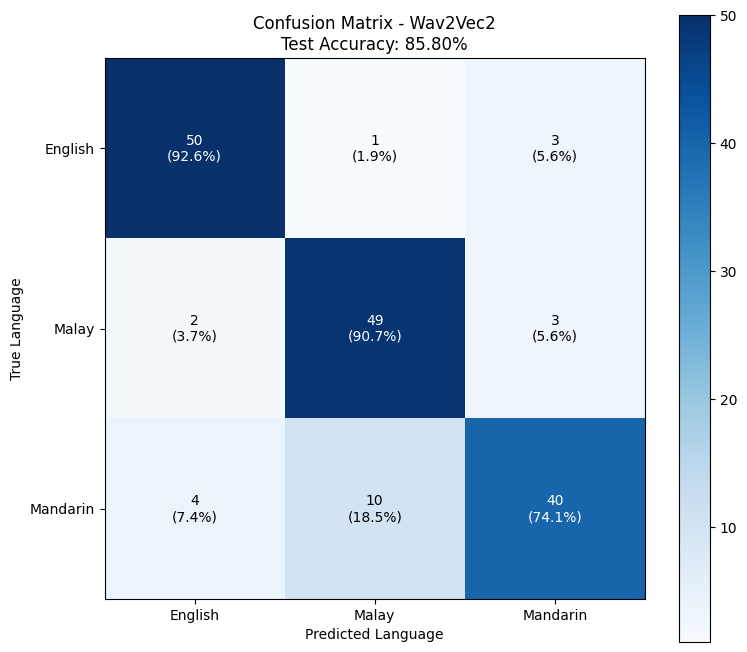

Saved: wav2vec2_confusion_matrix.png


In [8]:
# Confusion Matrix (counts + row %), save as PNG
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Prefer existing confusion matrix if already available
if 'cm' in globals():
    cm_plot = np.array(cm)
    test_acc = None
elif 'all_labels' in globals() and 'all_preds' in globals():
    cm_plot = confusion_matrix(all_labels, all_preds, labels=[0, 1, 2])
    test_acc = 100.0 * (np.array(all_preds) == np.array(all_labels)).sum() / len(all_labels)
else:
    # Fallback: load from saved metrics file
    import json
    with open('wav2vec2_metrics_summary.json', 'r') as f:
        metrics = json.load(f)
    cm_plot = np.array(metrics['confusion_matrix'])
    test_acc = metrics.get('test_accuracy', None)

lang_names_ordered = ['English', 'Malay', 'Mandarin']
row_totals = cm_plot.sum(axis=1, keepdims=True)
row_totals[row_totals == 0] = 1
row_perc = (cm_plot / row_totals) * 100.0

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(cm_plot, cmap=plt.cm.Blues)
ax.figure.colorbar(im, ax=ax)

acc_title = f"Test Accuracy: {test_acc:.2f}%" if test_acc is not None else ""
ax.set(
    xticks=np.arange(len(lang_names_ordered)),
    yticks=np.arange(len(lang_names_ordered)),
    xticklabels=lang_names_ordered,
    yticklabels=lang_names_ordered,
    ylabel='True Language',
    xlabel='Predicted Language',
    title=f"Confusion Matrix - Wav2Vec2\n{acc_title}".strip()
)

# Annotate counts and row %
thresh = cm_plot.max() / 2.0 if cm_plot.size else 0
for i in range(cm_plot.shape[0]):
    for j in range(cm_plot.shape[1]):
        ax.text(
            j,
            i,
            f"{cm_plot[i, j]}\n({row_perc[i, j]:.1f}%)",
            ha='center',
            va='center',
            color='white' if cm_plot[i, j] > thresh else 'black'
        )

plt.tight_layout()
plt.savefig('wav2vec2_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: wav2vec2_confusion_matrix.png")

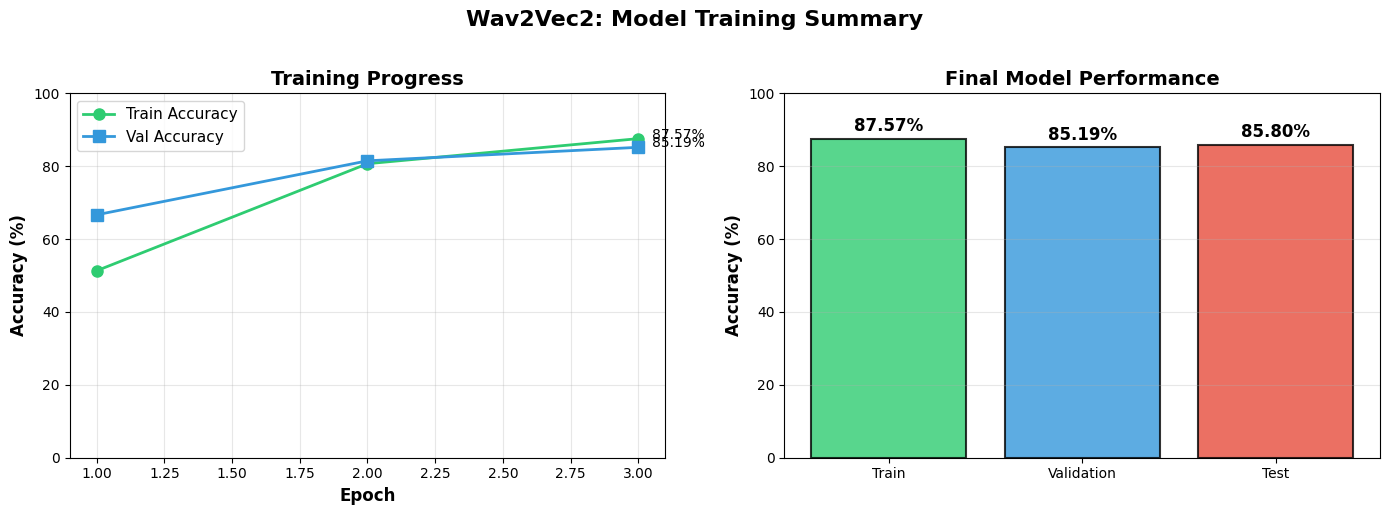

Saved: wav2vec2_accuracy_summary.png


In [20]:
# Visualization 3: Train/Val/Test Accuracy Summary
if 'train_history' in globals() and 'val_history' in globals() and 'acc' in globals():
    import matplotlib.pyplot as plt
    import numpy as np
    
    # Training curves
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Left: Training and validation accuracy over epochs
    epochs = range(1, len(train_history) + 1)
    ax1.plot(epochs, train_history, 'o-', label='Train Accuracy', linewidth=2, markersize=8, color='#2ecc71')
    ax1.plot(epochs, val_history, 's-', label='Val Accuracy', linewidth=2, markersize=8, color='#3498db')
    ax1.set_xlabel('Epoch', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Accuracy (%)', fontsize=12, fontweight='bold')
    ax1.set_title('Training Progress', fontsize=14, fontweight='bold')
    ax1.legend(fontsize=11)
    ax1.grid(alpha=0.3)
    ax1.set_ylim([0, 100])
    
    # Annotate final values
    final_train = train_history[-1]
    final_val = val_history[-1]
    ax1.annotate(f'{final_train:.2f}%', xy=(len(epochs), final_train), 
                xytext=(10, 0), textcoords='offset points', fontsize=10)
    ax1.annotate(f'{final_val:.2f}%', xy=(len(epochs), final_val), 
                xytext=(10, 0), textcoords='offset points', fontsize=10)
    
    # Right: Final accuracy comparison
    accuracies = [train_history[-1], val_history[-1], acc]
    labels = ['Train', 'Validation', 'Test']
    colors = ['#2ecc71', '#3498db', '#e74c3c']
    
    bars = ax2.bar(labels, accuracies, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
    ax2.set_ylabel('Accuracy (%)', fontsize=12, fontweight='bold')
    ax2.set_title('Final Model Performance', fontsize=14, fontweight='bold')
    ax2.set_ylim([0, 100])
    ax2.grid(axis='y', alpha=0.3)
    
    # Add value labels on bars
    for bar, val in zip(bars, accuracies):
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height + 1,
                f'{val:.2f}%', ha='center', va='bottom', fontsize=12, fontweight='bold')
    
    plt.suptitle('Wav2Vec2: Model Training Summary', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig('wav2vec2_accuracy_summary.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("Saved: wav2vec2_accuracy_summary.png")
else:
    print("Run training and evaluation cells first")


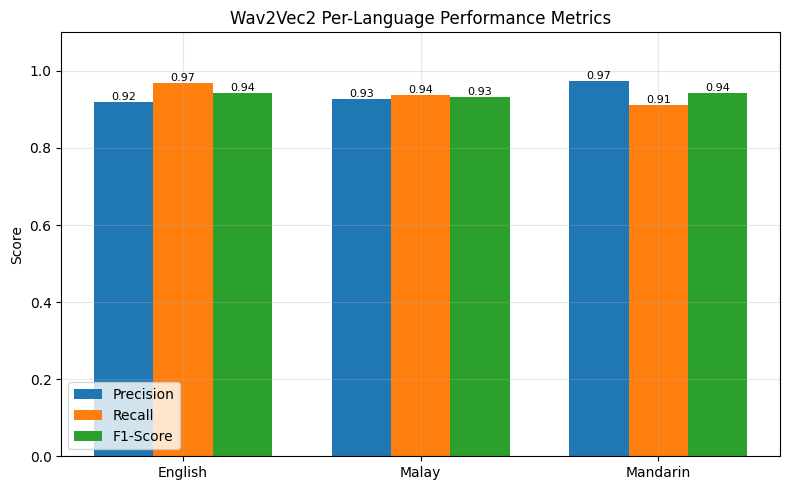

In [3]:
# Wav2Vec2 7.5h Per-Language Performance Metrics
import numpy as np
import matplotlib.pyplot as plt

LANG_NAMES = ['English', 'Malay', 'Mandarin']

# Newest Wav2Vec2 7.5h results
precision = np.array([0.9202, 0.9268, 0.9736])
recall    = np.array([0.9679, 0.9383, 0.9111])
f1        = np.array([0.9434, 0.9325, 0.9413])

fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(LANG_NAMES))
width = 0.25

bars1 = ax.bar(x - width, precision, width, label='Precision')
bars2 = ax.bar(x, recall, width, label='Recall')
bars3 = ax.bar(x + width, f1, width, label='F1-Score')

ax.set_xticks(x)
ax.set_xticklabels(LANG_NAMES)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score')
ax.set_title('Wav2Vec2 Per-Language Performance Metrics')
ax.legend()
ax.grid(True, alpha=0.3)

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2.,
            height,
            f'{height:.2f}',
            ha='center',
            va='bottom',
            fontsize=8
        )

plt.tight_layout()

plt.show()



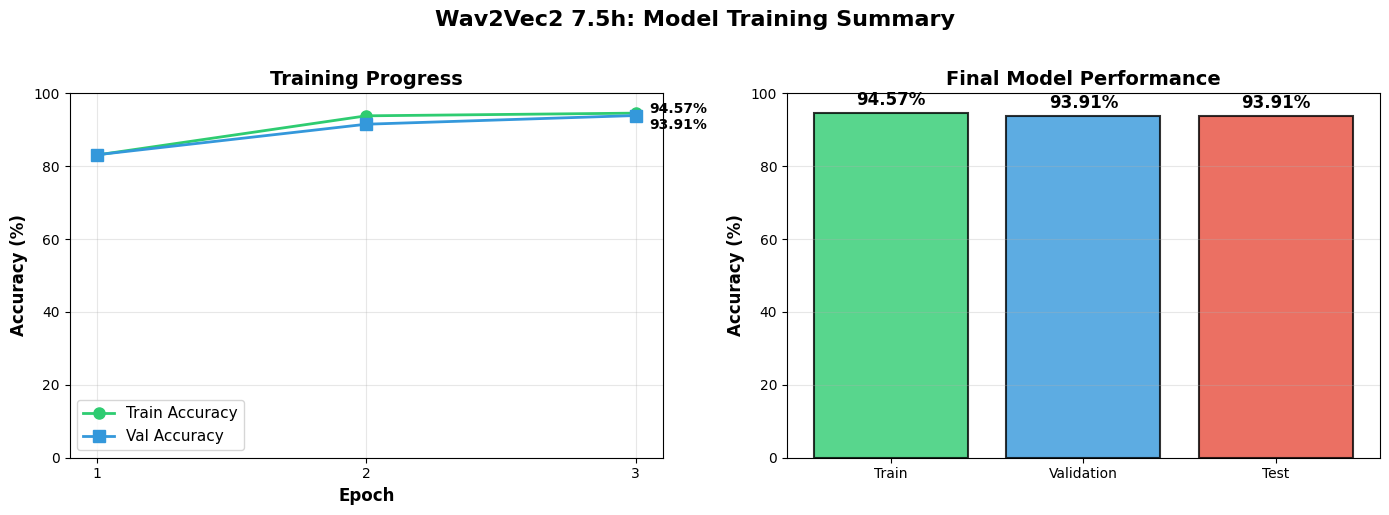

Saved: wav2vec2_7p5h_accuracy_summary.png


In [4]:
# Visualization: Wav2Vec2 7.5h Train/Val/Test Accuracy Summary
import matplotlib.pyplot as plt
import numpy as np

# Latest results from wav2vec2_final_metrics_7p5h.json
train_history = [83.0688, 93.8272, 94.5679]
val_history   = [83.1276, 91.5226, 93.9095]
test_acc      = 93.9095

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left: Training and validation accuracy over epochs
epochs = range(1, len(train_history) + 1)

ax1.plot(
    epochs, train_history,
    'o-', label='Train Accuracy',
    linewidth=2, markersize=8, color='#2ecc71'
)

ax1.plot(
    epochs, val_history,
    's-', label='Val Accuracy',
    linewidth=2, markersize=8, color='#3498db'
)

ax1.set_xlabel('Epoch', fontsize=12, fontweight='bold')
ax1.set_ylabel('Accuracy (%)', fontsize=12, fontweight='bold')
ax1.set_title('Training Progress', fontsize=14, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(alpha=0.3)
ax1.set_ylim([0, 100])
ax1.set_xticks(list(epochs))

# Annotate final values
final_train = train_history[-1]
final_val = val_history[-1]

ax1.annotate(
    f'{final_train:.2f}%',
    xy=(len(train_history), final_train),
    xytext=(10, 0),
    textcoords='offset points',
    fontsize=10,
    fontweight='bold'
)

ax1.annotate(
    f'{final_val:.2f}%',
    xy=(len(val_history), final_val),
    xytext=(10, -10),
    textcoords='offset points',
    fontsize=10,
    fontweight='bold'
)

# Right: Final accuracy comparison
accuracies = [train_history[-1], val_history[-1], test_acc]
labels = ['Train', 'Validation', 'Test']
colors = ['#2ecc71', '#3498db', '#e74c3c']

bars = ax2.bar(
    labels,
    accuracies,
    color=colors,
    alpha=0.8,
    edgecolor='black',
    linewidth=1.5
)

ax2.set_ylabel('Accuracy (%)', fontsize=12, fontweight='bold')
ax2.set_title('Final Model Performance', fontsize=14, fontweight='bold')
ax2.set_ylim([0, 100])
ax2.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar, val in zip(bars, accuracies):
    height = bar.get_height()
    ax2.text(
        bar.get_x() + bar.get_width() / 2.,
        height + 1,
        f'{val:.2f}%',
        ha='center',
        va='bottom',
        fontsize=12,
        fontweight='bold'
    )

plt.suptitle(
    'Wav2Vec2 7.5h: Model Training Summary',
    fontsize=16,
    fontweight='bold',
    y=1.02
)

plt.tight_layout()
plt.savefig('wav2vec2_7p5h_accuracy_summary.png', dpi=300, bbox_inches='tight')
plt.show()

print("Saved: wav2vec2_7p5h_accuracy_summary.png")